Notebook 1, Module 1, Data and Data Management, CAS Applied Data Science, 2024-08-22, A. Mühlemann, University of Bern. (based on the template by S. Haug)


# 1. Visualisation of Data - Examples

**Learning outcomes:**

Participants will be able to make good data science plots, with praxis on
- plot line charts from series and dataframes
- plot histograms
  - understand the effect of binning
- plot scatter plots
- plot box plots
- plot error bars
- formatting of plots
- geoplotting

**Introduction Slides**
- https://drive.google.com/file/d/12hehfcdVOR0lpemy5Y-84EspCiOjr8e9/view?usp=sharing

**Further sources**
- Python: https://pandas.pydata.org/pandas-docs/stable/visualization.html
- https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html
- Get inspired here : https://matplotlib.org/gallery/index.html

Here you have examples on plotting possibilities with pandas. They make data science plotting very easy and fast. However, you may have special needs that are not supported. Then you can use the underlaying plotting module **matplotlib**.

Plotting is an art and you can spend enourmous amounts of time doing plotting. There are many types of plots. You may invent your own type. We only show some examples and point out some important things. If you need to go further, you have to work indepentently.

Some vocabulary and plots are only understandable with corresponding statistics background. This is part of module 2.

## 0. Load the modules

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1. Line charts
Since line charts are for time series we use a time series data set for this visualization. On ILIAS you can find a data set called *garbage.csv* containing the garbage of in kg/inhabitant in Liestal, Basel, from 2017-2024 divided into different types of garbage. We first need to upload this data set to python and make a dataframe out of it.

In [ ]:
from google.colab import files
uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [7]:
garbage = pd.read_csv('garbage.csv', sep=";")
garbage

,Jahr,Gemeinde,Kategorie,Einheit,Wert
0,2017,Liestal,Glas,kg pro Einw.,28.670000
1,2017,Liestal,Gruengut,kg pro Einw.,65.583000
2,2017,Liestal,Hauskehricht + Sperrgut,kg pro Einw.,18.820000
3,2017,Liestal,Kunststoffe,kg pro Einw.,0.000000
4,2017,Liestal,Oele,kg pro Einw.,0.010000
5,2017,Liestal,Papier + Karton,kg pro Einw.,51.260000
6,2017,Liestal,Uebrige Metalle,kg pro Einw.,0.000000
7,2017,Liestal,Weissblech + Alu,kg pro Einw.,2.010000
8,2018,Liestal,Glas,kg pro Einw.,29.045658
9,2018,Liestal,Gruengut,kg pro Einw.,63.627199


Let us now plot the time series of "Hauskehricht + Sperrgut"

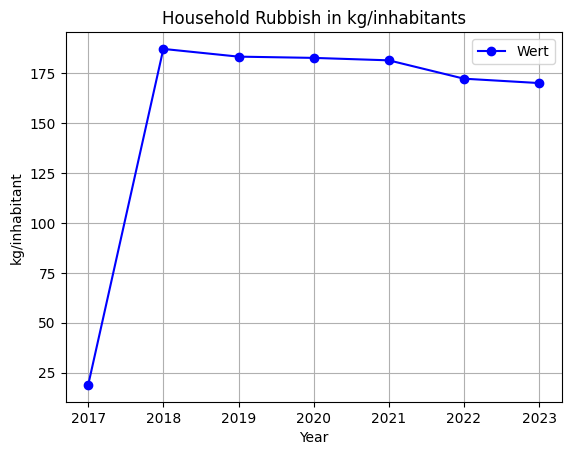

In [8]:
# Plot using pandas' built-in plot function
household_rubbish = garbage[garbage['Kategorie']=='Hauskehricht + Sperrgut']
household_rubbish.plot(x='Jahr', y='Wert', kind='line', marker='o', linestyle='-', color='b')

# Customize the plot
plt.xlabel('Year')
plt.ylabel('kg/inhabitant')
plt.grid(True)
plt.legend()
plt.title("Household Rubbish in kg/inhabitants")
# Display the plot
plt.show()


### Exercise
What about a plot containing all garbage types?

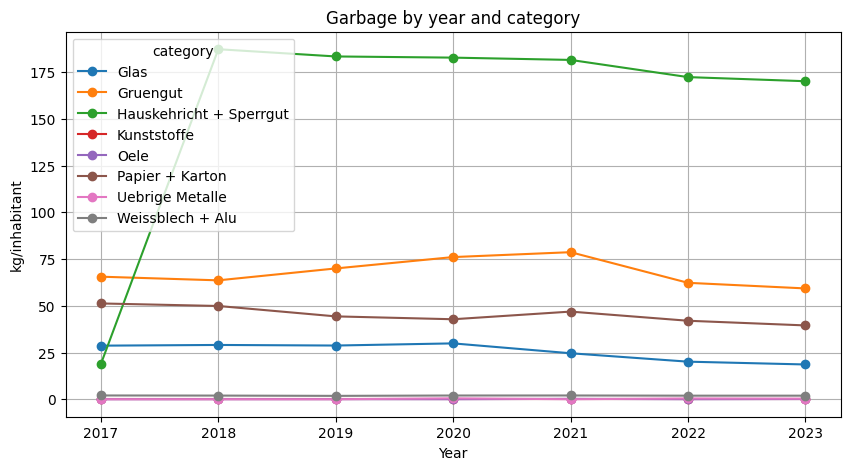

In [9]:
plt.figure(figsize = (10,5)) # Adjusting the length of the graph
for label, df_group in garbage.groupby('Kategorie'):
    plt.plot(df_group['Jahr'], df_group['Wert'], marker='o', linestyle='-', label=label) # Iterates through the Kategorie column and plots graph

# Customize the plot
plt.xlabel('Year')
plt.ylabel('kg/inhabitant')
plt.title('Garbage by year and category')
plt.legend(title='category')
plt.grid(True)

# Display the plot
plt.show()

## 2. Histograms
For this we use the dataset *sleep.csv* from yesterday.

In [10]:
url = 'https://github.com/KGzB/CAS-Applied-Data-Science/blob/master/Module-1/merged.csv?raw=true'
sleep = pd.read_csv(url, sep=',')
new_data = sleep.dropna()
new_data

,Unnamed: 0,Species,BodyWt,BrainWt,NonDreaming,Dreaming,TotalSleep,LifeSpan,Gestation,Predation,Exposure,Danger
1,1,Africangiantpouchedrat,1.000,6.60,6.3,2.0,8.3,4.5,42.0,3,1,3
4,4,Asianelephant,2547.000,4603.00,2.1,1.8,3.9,69.0,624.0,3,5,4
5,5,Baboon,10.550,179.50,9.1,0.7,9.8,27.0,180.0,4,4,4
6,6,Bigbrownbat,0.023,0.30,15.8,3.9,19.7,19.0,35.0,1,1,1
7,7,Braziliantapir,160.000,169.00,5.2,1.0,6.2,30.4,392.0,4,5,4
8,8,Cat,3.300,25.60,10.9,3.6,14.5,28.0,63.0,1,2,1
9,9,Chimpanzee,52.160,440.00,8.3,1.4,9.7,50.0,230.0,1,1,1
10,10,Chinchilla,0.425,6.40,11.0,1.5,12.5,7.0,112.0,5,4,4
11,11,Cow,465.000,423.00,3.2,0.7,3.9,30.0,281.0,5,5,5
14,14,EasternAmericanmole,0.075,1.20,6.3,2.1,8.4,3.5,42.0,1,1,1


Plot a histogram for the lifespan of the mammals.

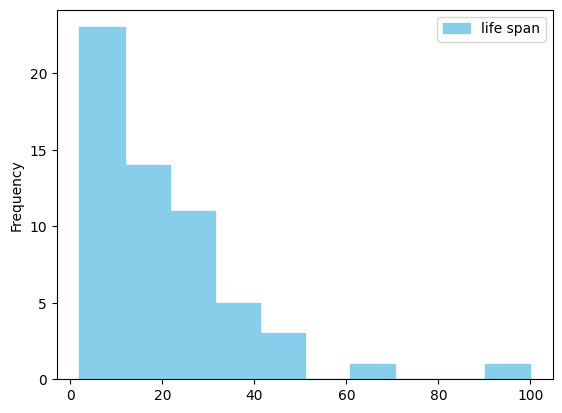

In [11]:
sleep['LifeSpan'].plot(kind="hist",fill=True,histtype='step',label='life span', color = "skyblue")
plt.legend()
plt.show()

### The effect of binning

When data is binned (or sampled) the bin size effects the amount of counts in each bin. Counts fluctuate like a normal distribution for counts above about 20. So depending on your bin size, the same data may look differently.

Hard binning (small bin size) may introduce pure statistical structures without any other meaning. This is then overfitting. Too big bin sizes may wipe out structures in the data (underfitting). If known, a bin size guided by the physical resolution of the sensor is close to optimal.

Plot the same histograms with a different binning.

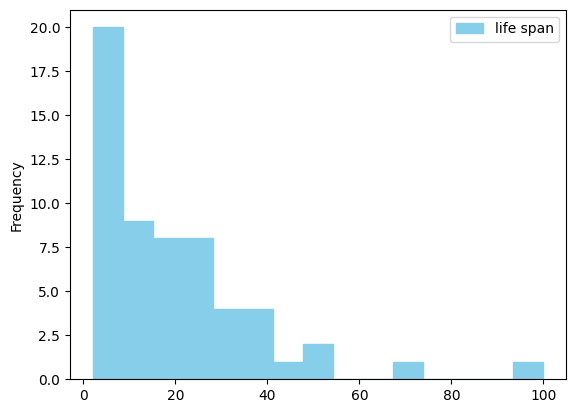

In [12]:
sleep['LifeSpan'].plot(kind="hist",fill=True,histtype='step',label='life span', color = "skyblue", bins=15)
plt.legend()
plt.show()

### Exercise
Plot a histogram for *Dreaming* and add *NonDreaming* to the same Histogram and add a legend.


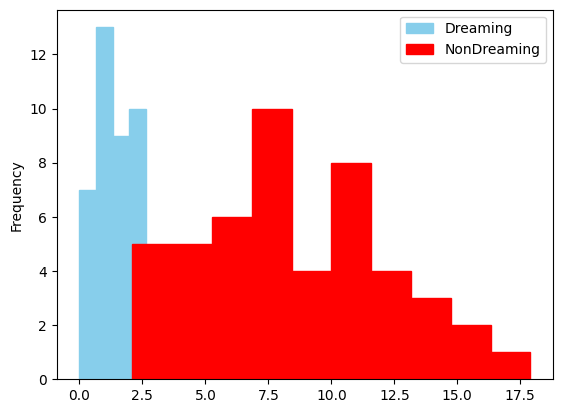

In [13]:
sleep['Dreaming'].plot(kind="hist",fill=True,histtype='step',label='Dreaming', color = "skyblue")
sleep['NonDreaming'].plot(kind="hist",fill=True,histtype='step',label='NonDreaming', color = "Red")
plt.legend() # Labelling the colours in the graph
plt.show()

Add label to the axes of the above plot

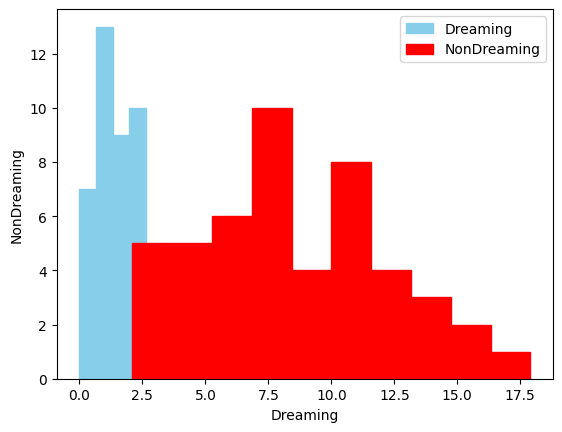

In [14]:
sleep['Dreaming'].plot(kind="hist",fill=True,histtype='step', color = "skyblue")
sleep['NonDreaming'].plot(kind="hist",fill=True,histtype='step', color = "Red")
plt.xlabel('Dreaming')
plt.ylabel('NonDreaming')
plt.legend()# Labelling different elements in the graphs
plt.show()

## 3. Pie Charts
Pie charts show the percentage on a whole.
Let us look at the percentage an asian elephant spents dreaming.

In [15]:
sleep[sleep['Species'] == 'Asianelephant'][['NonDreaming', 'Dreaming']]

,NonDreaming,Dreaming
4,2.1,1.8


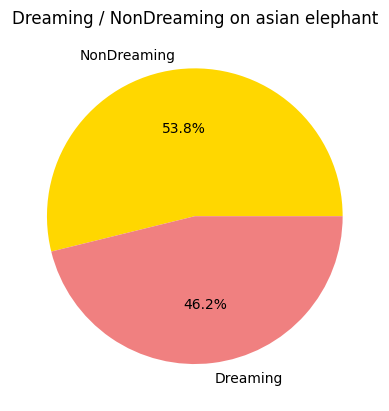

In [16]:
plt.pie(sleep[sleep['Species'] == 'Asianelephant'][['NonDreaming', 'Dreaming']].values.flatten(), labels=['NonDreaming', 'Dreaming'],
        autopct='%1.1f%%', colors = ['gold', 'lightcoral'])
plt.title('Dreaming / NonDreaming on asian elephant')
plt.show()

### Exercise
Plot pie charts of three species next to each other

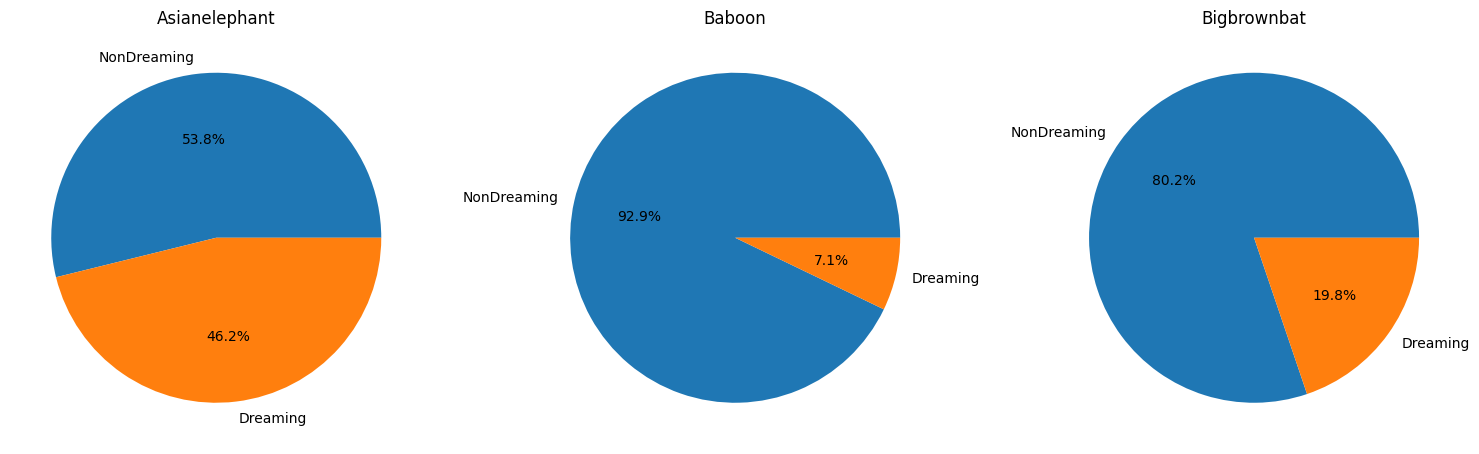

In [17]:
subset = sleep[4:7][['Species','NonDreaming', 'Dreaming']]
# Number of species
n_species = subset.shape[0]

# Create a figure and a set of subplots
fig, axs = plt.subplots(1, n_species, figsize=(15, 5))

# Loop through each species to create a pie chart
for i, species in enumerate(subset['Species']):
    sizes = subset[subset['Species'] == species][['NonDreaming', 'Dreaming']].values.flatten()
    axs[i].pie(sizes, labels=['NonDreaming', 'Dreaming'], autopct='%1.1f%%')
    axs[i].set_title(species)

# Display the pie charts
plt.tight_layout()
plt.show()


## 4. Scatter plots

Scatter plots show how the data is distributed in two dimensions. They are good for finding (anti) correlations between two variables. Let us check whether there is a correlation between total sleep and the time spent dreaming.

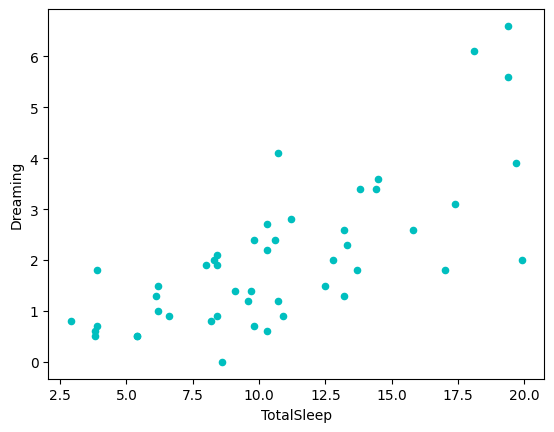

In [18]:
sleep.plot(x='TotalSleep',y='Dreaming',kind="scatter",c='c')
plt.show()

### Exercise
Can you find a correlation between sleep and dreaming when you plot a different scatterplot for each level of exposure?

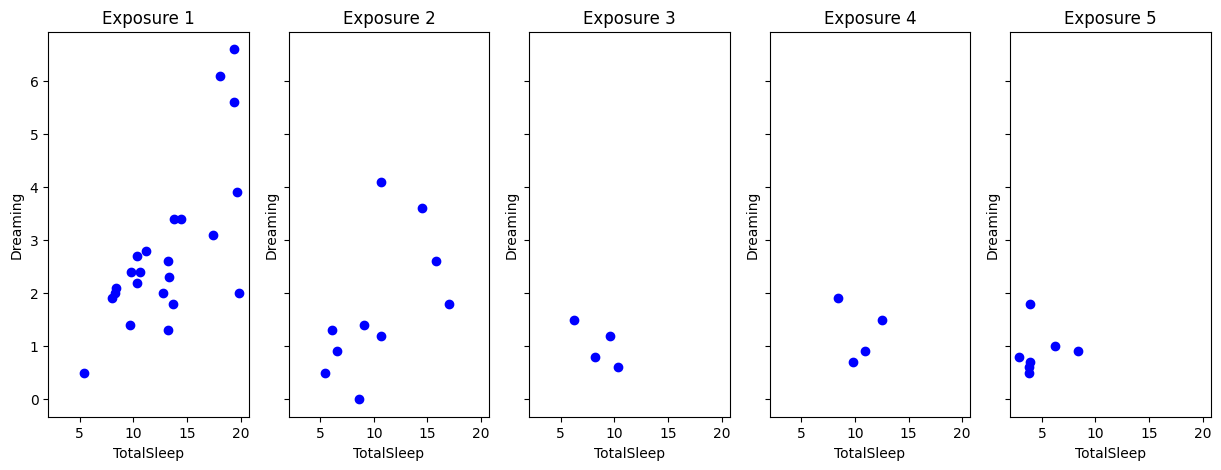

In [19]:
categories = [1,2,3,4,5]
n_categories = len(categories) # Number of categories

fig, axs = plt.subplots(1, n_categories, figsize=(15, 5), sharex=True, sharey=True) # Fixed size of the graph
for i, category in enumerate(categories): # Loops through the list from the file
    category_data = sleep[sleep['Exposure'] == category]
    axs[i].scatter(category_data['TotalSleep'], category_data['Dreaming'], color='b')
    axs[i].set_title(f'Exposure {category}')
    axs[i].set_xlabel('TotalSleep')
    axs[i].set_ylabel('Dreaming')

plt.show()

There are several other tools too. See https://pandas.pydata.org/pandas-docs/stable/visualization.html

## 4. Box plots

A boxplot is a graphical representation that shows the distribution of a dataset by displaying its minimum, first quartile, median, third quartile, and maximum, along with any potential outliers. We will look at them in more detail in Module 2

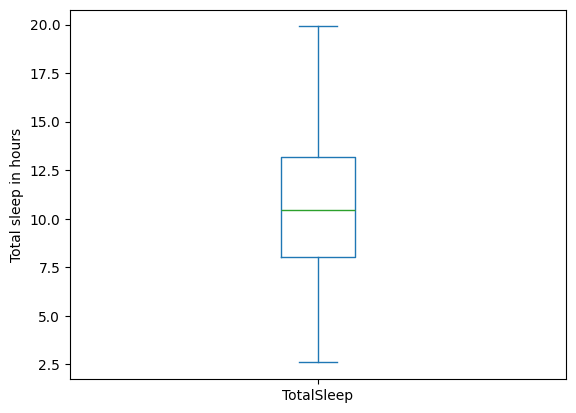

In [20]:
sleep['TotalSleep'].plot.box()
plt.ylabel("Total sleep in hours")
plt.show()

## 5. Plotting with error bars

There is no science without error bars, or better, uncertainties. The meaning of uncertainties is discussed in module 2. Here we only show by example  how to plot uncertainties.

Plotting with error bars is supported in DataFrame.plot() and Series.plot().

Horizontal and vertical error bars can be supplied to the xerr and yerr keyword arguments to plot(). The error values can be specified using a variety of formats:

- As a DataFrame or dict of errors with column names matching the columns attribute of the plotting DataFrame or matching the name attribute of the Series.
- As a str indicating which of the columns of plotting DataFrame contain the error values.
- As raw values (list, tuple, or np.ndarray). Must be the same length as the plotting DataFrame/Series.

Asymmetrical error bars are also supported, however raw error values must be provided in this case. For a M length Series, a Mx2 array should be provided indicating lower and upper (or left and right) errors. For a MxN DataFrame, asymmetrical errors should be in a Mx2xN array.

Here is an example using an error dataframe (symmetric uncertainties).

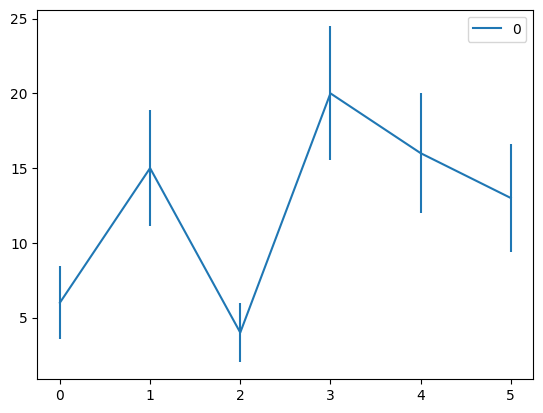

In [21]:
my_df   = pd.DataFrame([6,15,4,20,16,13]) # Some random data
my_df_e = (my_df)**0.5 # The error dataframe
my_df.plot(yerr=my_df_e)
plt.show()

## 6. Formatting plots

Plots can easily be formatted with keywords. One can adjust colors, types of shading, lines, axes, legends, titles, etc. Some formatting has been exemplified above. More examples are in the documentation. https://pandas.pydata.org/pandas-docs/stable/visualization.html

With the matplotlib module you are even more flexible. See https://matplotlib.org/gallery/index.html for inspirations.

## 7. Summary

- Do you remember three important plot types?
- What can the binning of a histogram do to the interpretation of it?
- Can you mention three important points to include in plots and their figure legends?


## 8. Plotting Geodata

Often is very nice to visualise data on geographical maps. Fortunately people have written packages helpin us with that. This is an example how the geopandas package can be used.


First we need the so called shape files. They are provided by [swisstopo](https://www.swisstopo.admin.ch/en/geodata/landscape/boundaries3d.html/). For convenience there is a version on the CAS github repositoy.

On Linux (colab is running linux) we get and unpack the files like this:



In [22]:
! wget https://github.com/sigvehaug/CAS-Applied-Data-Science/raw/master/Module-1/CHE_adm.zip
! mkdir -p data
! unzip CHE_adm.zip -d data

--2025-10-01 16:03:41--  https://github.com/sigvehaug/CAS-Applied-Data-Science/raw/master/Module-1/CHE_adm.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/sigvehaug/CAS-Applied-Data-Science/master/Module-1/CHE_adm.zip [following]
--2025-10-01 16:03:42--  https://raw.githubusercontent.com/sigvehaug/CAS-Applied-Data-Science/master/Module-1/CHE_adm.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3559904 (3.4M) [application/zip]
Saving to: ‘CHE_adm.zip’

CHE_adm.zip         100%[===================>]   3.39M  --.-KB/s    in 0.07s   

2025-10-01 16:03:42 (47.9 MB/s) - ‘CHE_adm.zip’ saved [355

In [23]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import datetime
import os


Now we merge some numbers per canton (covid cases at some point in the past) with the shape files.

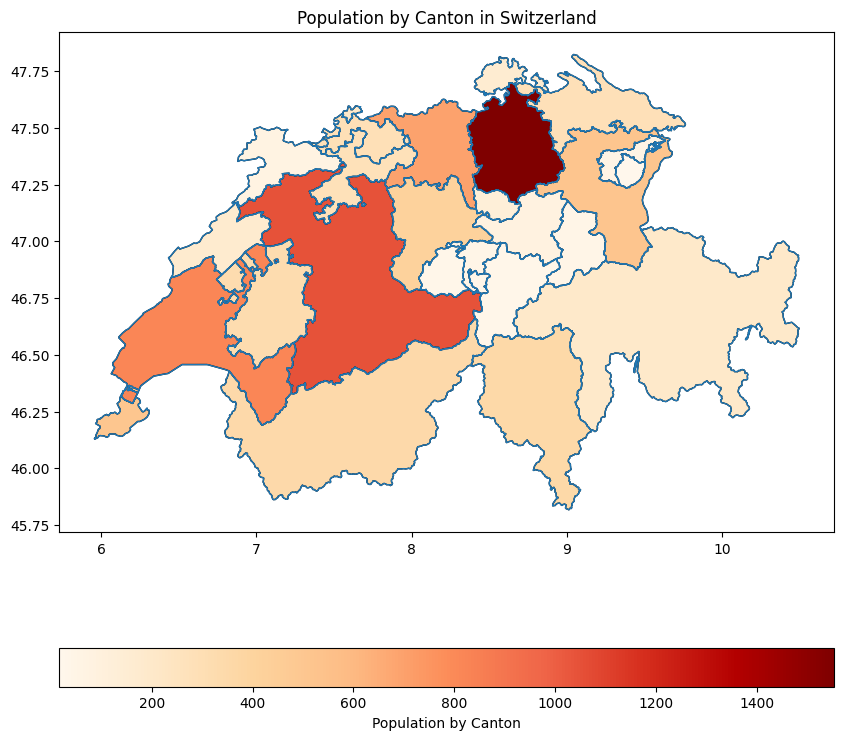

In [24]:
shape_file = 'data/CHE_adm1.shp'
switzerland = gpd.read_file(shape_file)
population_data = {
    'canton': ['Aargau', 'Appenzell Ausserrhoden', 'Appenzell Innerrhoden', 'Basel-Landschaft', 'Basel-Stadt',
               'Bern', 'Fribourg', 'Genève', 'Glarus', 'Graubünden', 'Jura', 'Lucerne',
               'Neuchâtel', 'Nidwalden', 'Obwalden', 'Schwyz', 'Schaffhausen', 'Solothurn',
               'Sankt Gallen', 'Thurgau', 'Ticino', 'Uri', 'Valais', 'Vaud', 'Zug', 'Zürich'],
    'population': [695.3, 55.7, 16.3, 291.3, 196.6, 1046.3, 325.2, 509.1, 40.7,
                   198.9, 73.8, 416.3, 177.3, 43.9, 38.4, 83.6, 162.6, 278.3,
                   516.7, 282.9, 353.3, 37, 349.2, 815.6, 130.2, 1553.6]
}

population_df = pd.DataFrame(population_data)
population_df

# Filter for Switzerland and merge with population data
switzerland = switzerland[switzerland['NAME_1'].isin(population_df['canton'])]
switzerland = switzerland.merge(population_df, left_on ='NAME_1', right_on ='canton')
switzerland

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
switzerland.boundary.plot(ax=ax, linewidth=1)  # Plot boundaries
switzerland.plot(column='population', ax=ax, legend=True,
                 legend_kwds={'label': "Population by Canton",
                              'orientation': "horizontal"},
                cmap='OrRd', edgecolor='black')

# Title and show plot
plt.title('Population by Canton in Switzerland')
plt.show()

### Excercise
Draw another geoplot of Switzerland.

# Exercise 12 (continued)
Investigate the merged datasets from yesterdays Exercise 12 using suitable graphical tools